# Step 1 — Load the Hybrid Matrix

In [6]:
import numpy as np
import faiss

hybrid_matrix = np.load('../embeddings/hybrid_matrix.npy').astype('float32')
# FAISS requires float32; embeddings are often float64 by default
print(f"Matrix shape: {hybrid_matrix.shape}")
print(f"dtype: {hybrid_matrix.dtype}")

Matrix shape: (89740, 394)
dtype: float32


# Step 2 — Choose the Right Index Type

For this project, you have three reasonable choices:

| Index | How It Works | When to Use |
|---|---|---|
| `IndexFlatL2` | Brute force, exact | Small datasets (<100k), debugging |
| `IndexFlatIP` | Brute force inner product (cosine if normalized) | Same as above, L2-normalized vectors |
| `IndexIVFFlat` | Clusters vectors into buckets, searches only nearest buckets | Large datasets, good speed/accuracy tradeoff |
| `IndexHNSWFlat` | Graph-based, very fast query, no training needed | Production-grade, best for your use case |

Use `IndexHNSWFlat` for this project. It requires no training and has excellent query speed with high recall, although it consumes more RAM since it relies on graphic connections for neighbouring search:

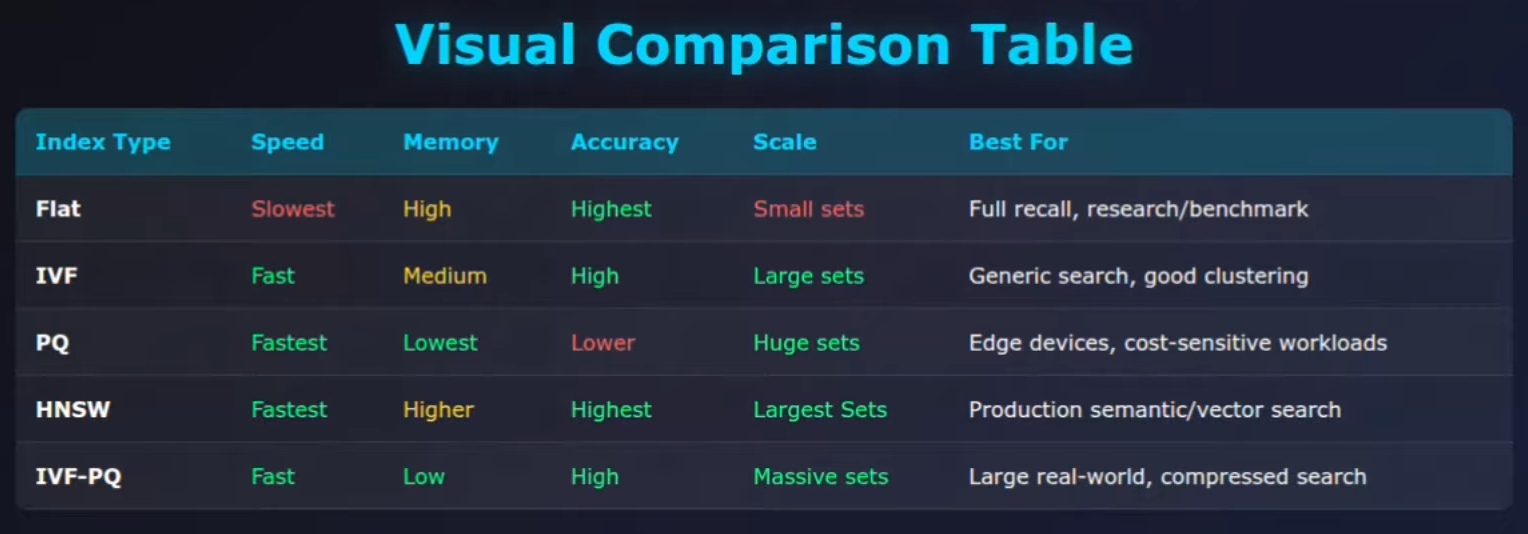

In [7]:
d = hybrid_matrix.shape[1] # Dimension of vectors (394)
M = 32 # Number of neighbors to connect in the graph, the higher the M, the better the precison with more RAM usage

index = faiss.IndexHNSWFlat(d, M)
index.hnsw.efConstruction = 200 # Quality of index construction. Higher = better but slower build.
index.hnsw.efSearch = 100 # Quality of search. Higher = better recall but slower query.

#Add all vectors
index.add(hybrid_matrix)
print(f"Index trained: {index.is_trained}")
print(f"Total vectors in index: {index.ntotal}")

Index trained: True
Total vectors in index: 89740


# Step 3 — Test the Index

Before saving, verify it works. Are the results reasonable? Similar genre? Similar energy/valence?

In [8]:
import pandas as pd

df = pd.read_csv('../data/processed/tracks_enriched_described.csv')

# Pick a track index to test
test_idx = 0
test_track = df.iloc[test_idx]
print(f"Query track: {test_track['track_name']} by {test_track['artists']}")

# Query the index
query_vector = hybrid_matrix[test_idx:test_idx+1] # Shape (1, 394)
k = 10 # Number of results

distances, indices = index.search(query_vector, k + 1) # +1 because query itself will appear

# Skip the query track itself (index 0)
results = indices[0][1:] # Remove self-match
for rank, idx in enumerate(results): # Return results by row starting from 0+1 at iloc[0] for 10 results (from k = 10 from index.search's k + 1 argument)
    track = df.iloc[idx]
    print(f" {rank+1}. {track['track_name']} by {track['artists']} [{track['track_genre']}]")

Query track: Comedy by Gen Hoshino
 1. Monde de fous by Danakil [dub]
 2. JAMAICA by Feid;Sech [pop]
 3. big by Koi [sad]
 4. Mistadobalina by Del The Funky Homosapien [hardcore]
 5. Bu A??k Olur Mu by MF?? [j-rock]
 6. Runnin' by The Pharcyde [hardcore]
 7. Noche De Sexo by Wisin & Yandel;Anthony Santos [electro]
 8. Noche De Sexo by Wisin & Yandel;Anthony Santos [electro]
 9. Say Wooee by Tanto Metro & Devonte [j-dance]
 10. Kungar av December by Danny Saucedo;Niello [swedish]


# Step 4 — Save the Index

In [9]:
faiss.write_index(index, '../index/faiss.index')
print("FAISS index saved.")

FAISS index saved.


# Step 5 — Benchmark Query 

Target: <10ms per query. If it's slower, reduce `efSearch` (controls how many candidate nodes FAISS explores while searching).

In [10]:
import time

N_QUERIES = 100
random_indices = np.random.choice(len(hybrid_matrix), N_QUERIES)
query_vectors = hybrid_matrix[random_indices].astype('float32')

start = time.time()
distances, indices = index.search(query_vectors, 10)
end = time.time()

print(f"Average query time: {(end - start) / N_QUERIES * 1000:.2f} ms")

Average query time: 0.08 ms
